# MODELO LIGHTGBM APLICADO A PETFINDER:
Este modelo pertenece a la familia de árboles de decisión. A diferencia de otros modelos crece por hojas lo que permite mayor reducción de pérdida comparado con otros modelos que crecen por niveles.

Se importan las librerías y los archivos que forman el dataset, incluído el archivo de train que aplicaremos a todos los modelos que probamos.

In [ ]:
# Se importan las librerias a utilizar 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, StratifiedKFold 
from sklearn.metrics import cohen_kappa_score, accuracy_score, balanced_accuracy_score 
from sklearn.utils import shuffle 
import lightgbm as lgb
from sklearn.preprocessing import OrdinalEncoder
import optuna
import lightgbm as lgb
# Se importan los archivos para formar los dataset 
breed_df = pd.read_csv(os.path.join(r"C:\Users\fchiavassa\Desktop\Nueva carpeta\Inteligencia Artificial\Codigos\Maestria\breed_labels.csv"))
color_df = pd.read_csv(os.path.join(r"C:\Users\fchiavassa\Desktop\Nueva carpeta\Inteligencia Artificial\Codigos\Maestria\color_labels.csv"))
state_df = pd.read_csv(os.path.join(r"C:\Users\fchiavassa\Desktop\Nueva carpeta\Inteligencia Artificial\Codigos\Maestria\state_labels.csv"))
ruta_archivo = r"C:\Users\fchiavassa\Desktop\Nueva carpeta\Inteligencia Artificial\Codigos\Maestria\df_train_FE_split.csv"
df_train = pd.read_csv(ruta_archivo, sep=',', encoding='latin-1')


Se agrega dataset de test

In [ ]:
ruta_archivo = r"C:\Users\fchiavassa\Desktop\Nueva carpeta\Inteligencia Artificial\Codigos\Maestria\df_test_FE_split.csv"

df_test = pd.read_csv(ruta_archivo, sep=',', encoding='latin-1')

Se comienza a adecuar el dataset para poder aplicas el modelo, definimos primero que columnas no queremos mostrar

In [ ]:
# Genero dataframes de train y test para tener los mismos datos en las diferentes pruebas
X_train = df_train.drop(columns=['AdoptionSpeed','PetID'])
y_train = df_train['AdoptionSpeed']

X_test = df_test.drop(columns=['AdoptionSpeed','PetID'])
y_test = df_test['AdoptionSpeed']

# Se definen las variables que son categóricas para asegurarse de que el modelo lo entienda, se convierte a tipo 'category' en pandas)

categorical_cols = ['Type', 'Breed1', 'Gender', 'Color1','Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State','Description','SizeCategory']

for col in categorical_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# ENTRENAMIENTO PREVIO:
Se hace un entrenamiento con hiperparametros estandar para obtener un resultado base el cual se va a ir comparando para ver si mejora el resultado 

In [ ]:
# Se configura K-Fold Cross Validation para hacer las 5 validaciones cruzadas
N_SPLITS = 5
folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Arreglos para guardar predicciones (Out-Of-Fold y Test)
oof_preds = np.zeros((len(X_train), 5)) # 5 es el número de clases
test_preds = np.zeros((len(X_test), 5))

# Nuevos parámetros base más controlados para probar
lgb_params = {
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_error',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'seed': 42,
    'verbose': -1
}

print("Iniciando entrenamiento con 5-Fold Cross Validation...")

for fold_, (trn_idx, val_idx) in enumerate(folds.split(X_train, y_train)):
    print(f"\\n--- Fold {fold_ + 1} ---")
    
    # Se separan los datos del fold
    X_tr, y_tr = X_train.iloc[trn_idx], y_train.iloc[trn_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    # Se Crean Datasets de LightGBM
    trn_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=categorical_cols)
    val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_cols, reference=trn_data)
    
    # Se entrena el modelo usando callbacks modernos
    clf = lgb.train(
        lgb_params,
        trn_data,
        num_boost_round=1000,
        valid_sets=[trn_data, val_data],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=100)
        ]
    )
    
    # Se predice sobre validación (Out-Of-Fold)
    oof_preds[val_idx] = clf.predict(X_val, num_iteration=clf.best_iteration)
    
    # Se predice sobre test (promediando los 5 folds)
    test_preds += clf.predict(X_test, num_iteration=clf.best_iteration) / N_SPLITS

# Se evalua el modelo ensamblado antes de la busqueda de hiperparametros optimos para comparar con lo obtenido
oof_predictions_classes = oof_preds.argmax(axis=1)
test_predictions_classes = test_preds.argmax(axis=1)

kappa_cv = cohen_kappa_score(y_train, oof_predictions_classes, weights='quadratic')
kappa_test = cohen_kappa_score(y_test, test_predictions_classes, weights='quadratic')

print(f"\\nScore Kappa de Validación Cruzada (OOF): {kappa_cv:.4f}")
print(f"Score Kappa final en Test Set: {kappa_test:.4f}")

Iniciando entrenamiento con 5-Fold Cross Validation...
\n--- Fold 1 ---
[100]	training's multi_error: 0.354768	valid_1's multi_error: 0.549396
\n--- Fold 2 ---
[100]	training's multi_error: 0.352267	valid_1's multi_error: 0.561901
\n--- Fold 3 ---
[100]	training's multi_error: 0.362897	valid_1's multi_error: 0.556482
\n--- Fold 4 ---
[100]	training's multi_error: 0.347473	valid_1's multi_error: 0.564402
\n--- Fold 5 ---
[100]	training's multi_error: 0.360254	valid_1's multi_error: 0.566722
\nScore Kappa de Validación Cruzada (OOF): 0.3983
Score Kappa final en Test Set: 0.3215


Se cambia columa SizeCategory para que sea un numero

In [ ]:
# Se define el diccionario para generar una variable numerica con el tamaño de los animales
mapeo_tamaños = {
    'PequeÃ±o': 1,
    'Mediano': 2,
    'Grande': 3
}

# Se aplica el cambio
df_train['SizeCategory'] = df_train['SizeCategory'].map(mapeo_tamaños)
df_test['SizeCategory'] = df_test['SizeCategory'].map(mapeo_tamaños)

In [ ]:
# Se definen las columnas
categorical_cols = ['Type', 'Breed1', 'Gender', 'Color1',
                    'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State']

# Se usa un codificador para transformar el texto/números en categorías numéricas consistentes
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Se ajusta con Train para transformar ambos
X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])

# Nos aseguramos que sean de tipo 'category'
for col in categorical_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

Se saca la columa de description ya que va a formar parte de otra prueba posterior

In [ ]:
# Se Genera el dataframes de train y test con sus respectivos targets para la busqueda de hiperparametros optimos
X_train = df_train.drop(columns=['AdoptionSpeed','Description'])
y_train = df_train['AdoptionSpeed']

X_test = df_test.drop(columns=['AdoptionSpeed','Description'])
y_test = df_test['AdoptionSpeed']


# BUSQUEDA DE HIPERPARÁMETROS OPTIMOS:
Se configura optuna para buscar los hiperparámetros optimos, el learning_rate en un valor bajo hace que el aprendizaje sea más lento y preciso, requiriendo más árboles por ejemplo un 0.05 hace que el modelo solo avance un 5% en esa dirección. El num_leaves determina cuántos hojas puede tener un solo árbol con lo cual si es alto permite al árbol capturar interacciones de variables sumamente complejas y profundaspero puede ser demasiado específico para el set de entrenamiento y destruye la capacidad de generalizar. El parametro min_child_samples es el minimos de datos que puede existir por hoja con lo cual valores altos hacen que eviten obtener casos aislados o ruido estadístico. Los lambdas se utilizan para la regularizacion del modelo, siendo el L1 (Lasso) el que empuja los pesos de las hojas que aportan poco valor directamente a cero y L2 (Ridge) por el contrario lo que hace es disminuir uniformemente todos los pesos de las hojas, asegurando que ninguno sea desproporcionadamente grande.
Se realiza una validación cruzada de 5 fold al igual que hacemos en el tabnet para generar un modelo mas robusto y ademas buscamos monitorear el sobreajuste mediante una métrica de control (el GAP) repitiendo el experimento 1000 veces hasta encontrar la mejor configuracion
El num_boost_round=5000 se utiliza para poner un limite de hasta 5000 árboles secuenciales para construir
En el caso de lgb.early_stopping(stopping_rounds=200) se utiliza para evitar el sobreajuste ya que si bien tiene permiso de hacer hasta 5000 árboles si la pérdida en el set de validación deja de mejorar durante 200 árboles seguidos, el entrenamiento se detiene se queda con el mejor árbol conseguido hasta ese momento.
.argmax(axis=1) se utiliza para examinar las 5 probabilidades fila por fila y se queda con el índice de la columna que tenga la probabilidad más alta.

In [ ]:
# Se comienza la busqueda de los hiperparametros optimos
def objective(trial):
    # 1. Espacio de búsqueda optimizado para combatir el overfitting
    param = {
        'objective': 'multiclass',
        'num_class': 5,
        'metric': 'multi_error',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.8, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 10, 200),
        'min_child_samples': trial.suggest_int('min_child_samples', 300, 3000), 
        'lambda_l1': trial.suggest_float('lambda_l1', 1.0, 50.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1.0, 50.0, log=True),
    }

    N_SPLITS = 5
    folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    
    train_scores = []
    val_scores = []
    gap_scores = []

    for trn_idx, val_idx in folds.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[trn_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[trn_idx], y_train.iloc[val_idx]
        
        trn_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=categorical_cols)
        val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_cols, reference=trn_data)
        
        clf = lgb.train(
            param, trn_data, num_boost_round=5000,
            valid_sets=[trn_data, val_data],
            callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)]
        )
        
        # Predicciones
        p_tr = clf.predict(X_tr).argmax(axis=1)
        p_val = clf.predict(X_val).argmax(axis=1)
        
        # Kappas por Fold 
        k_tr = cohen_kappa_score(y_tr, p_tr, weights='quadratic')
        k_val = cohen_kappa_score(y_val, p_val, weights='quadratic')
        
        train_scores.append(k_tr)
        val_scores.append(k_val)
        gap_scores.append(k_tr - k_val)

    # Promedios del Trial
    final_train_kappa = np.mean(train_scores)
    final_val_kappa = np.mean(val_scores)
    final_gap = np.mean(gap_scores)
    
    # Guardamos los atributos en Optuna para no perder el rastro
    trial.set_user_attr("train_kappa", final_train_kappa)
    trial.set_user_attr("val_kappa", final_val_kappa)
    trial.set_user_attr("gap", final_gap)
    
    # Imprimir el rendimiento exacto de esta corrida
    print(f"\n[Trial {trial.number}] -> Train Kappa: {final_train_kappa:.4f} | Val Kappa: {final_val_kappa:.4f} | GAP: {final_gap:.4f}")
    
    return final_val_kappa

# Ejecucion del estudio
study = optuna.create_study(direction='maximize', study_name="Petfinder_Optuna")
study.optimize(objective, n_trials=1000) 

print("\n--- RESULTADOS FINALES DE OPTUNA ---")
print(f"Mejor Corrida (Trial): #{study.best_trial.number}")
print(f"Mejor Kappa Entrenamiento: {study.best_trial.user_attrs['train_kappa']:.4f}")
print(f"Mejor Kappa Validación: {study.best_value:.4f}")
print(f"GAP del mejor modelo: {study.best_trial.user_attrs['gap']:.4f}")
print("Mejores parámetros:", study.best_params)

[I 2026-05-21 07:33:41,994] A new study created in memory with name: Petfinder_Optuna
[I 2026-05-21 07:33:49,738] Trial 0 finished with value: 0.36615195731933936 and parameters: {'learning_rate': 0.29049520817893093, 'num_leaves': 28, 'min_child_samples': 1429, 'lambda_l1': 3.6308638419694117, 'lambda_l2': 1.354318593629322}. Best is trial 0 with value: 0.36615195731933936.



[Trial 0] -> Train Kappa: 0.4438 | Val Kappa: 0.3662 | GAP: 0.0777


[I 2026-05-21 07:33:58,110] Trial 1 finished with value: 0.37437414266497004 and parameters: {'learning_rate': 0.3055711282477228, 'num_leaves': 173, 'min_child_samples': 1096, 'lambda_l1': 3.120213517867768, 'lambda_l2': 2.8600635163756154}. Best is trial 1 with value: 0.37437414266497004.



[Trial 1] -> Train Kappa: 0.4686 | Val Kappa: 0.3744 | GAP: 0.0942


[I 2026-05-21 07:34:02,158] Trial 2 finished with value: 0.3422317228380195 and parameters: {'learning_rate': 0.23636506803231722, 'num_leaves': 101, 'min_child_samples': 2776, 'lambda_l1': 2.5035224050815224, 'lambda_l2': 1.2034160821894564}. Best is trial 1 with value: 0.37437414266497004.


...


[Trial 997] -> Train Kappa: 0.6107 | Val Kappa: 0.3838 | GAP: 0.2269


[I 2026-05-21 13:28:08,073] Trial 998 finished with value: 0.37920817664523065 and parameters: {'learning_rate': 0.33484609334915133, 'num_leaves': 88, 'min_child_samples': 350, 'lambda_l1': 1.6164042735908806, 'lambda_l2': 1.1314160751888918}. Best is trial 300 with value: 0.3939021526721034.



[Trial 998] -> Train Kappa: 0.6050 | Val Kappa: 0.3792 | GAP: 0.2258


[I 2026-05-21 13:28:19,978] Trial 999 finished with value: 0.3814224759093309 and parameters: {'learning_rate': 0.08893459197443247, 'num_leaves': 77, 'min_child_samples': 496, 'lambda_l1': 2.056773568419448, 'lambda_l2': 1.2349980354270285}. Best is trial 300 with value: 0.3939021526721034.



[Trial 999] -> Train Kappa: 0.5514 | Val Kappa: 0.3814 | GAP: 0.1700

--- RESULTADOS FINALES DE OPTUNA ---
Mejor Corrida (Trial): #300
Mejor Kappa Entrenamiento: 0.5910
Mejor Kappa Validación: 0.3939
GAP del mejor modelo: 0.1971
Mejores parámetros: {'learning_rate': 0.09586323376644908, 'num_leaves': 77, 'min_child_samples': 300, 'lambda_l1': 2.2512173224589307, 'lambda_l2': 1.1077927131926015}


# Matriz de confusion
Se grafico una matriz de confusion para evaluar los resultados obtenidos

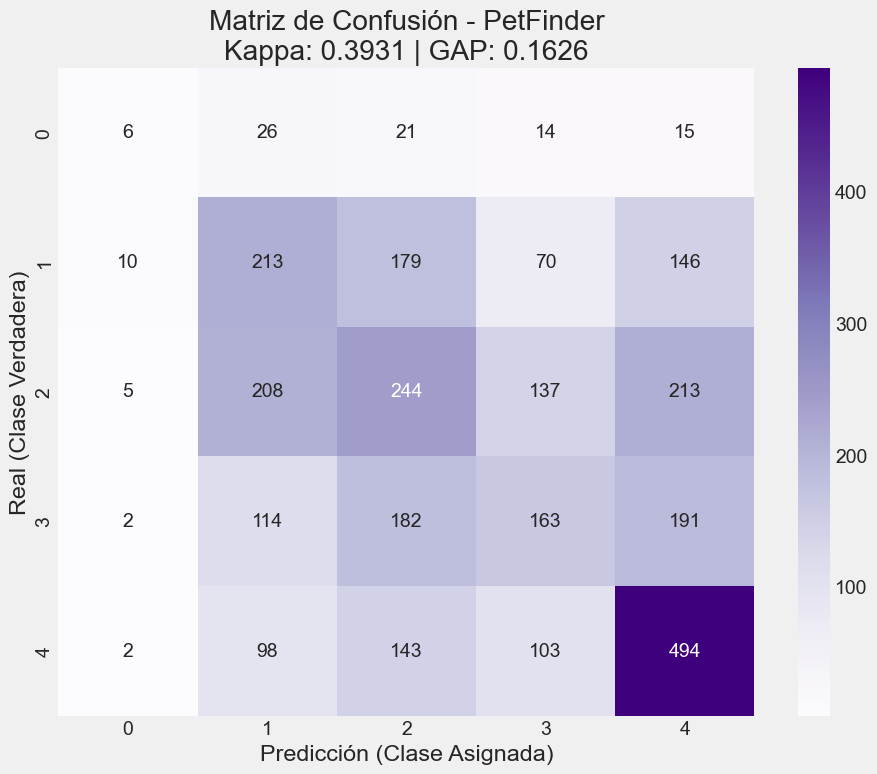

In [ ]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Preparación del Dataset de LightGBM
# Es crucial pasar 'categorical_feature' para que use los tipos 'category' que definimos
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)

# 2. Reentrenar con tus parámetros óptimos de Optuna
best_params = {
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_error',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'learning_rate': 0.09586323376644908,
    'num_leaves': 77,
    'min_child_samples': 300,
    'lambda_l1': 2.2512173224589307,
    'lambda_l2': 1.1077927131926015
}


# Entrenamos el modelo final
clf_final = lgb.train(best_params, train_data, num_boost_round=1000)

# 3. Predicciones en el set de TEST
# Nota: X_test debe haber pasado por el mismo proceso de limpieza y categorías que X_train
y_pred_probs = clf_final.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

# 4. Calcular y Visualizar la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['0', '1', '2', '3', '4'], 
            yticklabels=['0', '1', '2', '3', '4'])

plt.xlabel('Predicción (Clase Asignada)')
plt.ylabel('Real (Clase Verdadera)')
plt.title(f'Matriz de Confusión - PetFinder\nKappa: 0.3931 | GAP: 0.1626')
plt.show()